# Script to read in the 2D tomography models for both sites, and plot them as 1D columns
Geoff and Shubh did this at AGU, 2025


In [6]:
#  read Arnab's Refrapy output model. https://github.com/viictorjs/Refrapy
import numpy as np
from matplotlib import pyplot as plt
import csv
from matplotlib import ticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [2]:
# Line 1000 is Ski Lodge refraction. 
infile='1000_pick_xzv.txt'

xval = []
zval = []
vval = []

# Limit to points under the refraction line, 0 to 46 m
xmin = 0
xmax = 46

# Load the file, random-order x,z,Vp points.  
with open(infile, 'r') as csvfile:
    headerline = csvfile.readline()
    for line in csvfile:
        items = line.split()
        x = float(items[0])
        if (xmax>x>xmin):
            xval.append(float(items[0]))
            zval.append(float(items[1]))
            vval.append(float(items[2]))

vval=np.array(vval)
zval=-np.array(zval)
xval=np.array(xval)


In [3]:
# Now, make bins, bin the SL data
dz = 0.5
zbins = np.arange(0,20,dz)
vavs = np.zeros_like(zbins)
vstds = np.zeros_like(zbins)
for i, dep in enumerate(zbins):
    vv= vval[(np.abs(zval-dep)<dz/2)]
    vav = np.mean(vv)
    vavs[i]=vav
    vstds[i] = np.std(vv)

# plt.errorbar(vavs, zbins, xerr=vstds, ecolor='salmon')
# plt.ylim([17,0])
# plt.ylabel('depth, m')
# plt.xlabel('velocity, m/s')
# plt.title('average of Ski Lodge')
# plt.show()

/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/keyser/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


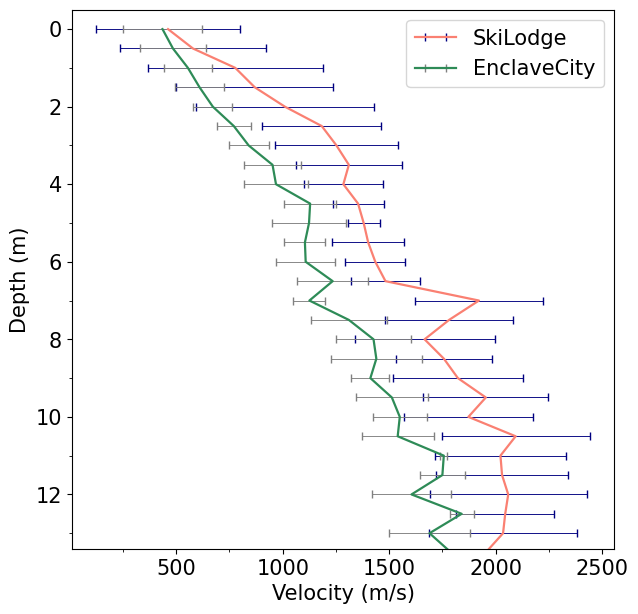

In [18]:
# now same for Enclave City, then plot them both
xval2 = []
zval2 = []
vval2 = []
xmin = 0
xmax = 46
infile='1002.sgt_xzv.txt'
with open(infile, 'r') as csvfile:
    headerline = csvfile.readline()
    for line in csvfile:
        items = line.split()
        x = float(items[0])
        if (xmax>x>xmin):
            xval2.append(float(items[0]))
            zval2.append(float(items[1]))
            vval2.append(float(items[2]))

vval2=np.array(vval2)
zval2=-np.array(zval2)
xval2=np.array(xval2)
dz = 0.5
zbins = np.arange(0,20,dz)
vavs2 = np.zeros_like(zbins)
vstds2 = np.zeros_like(zbins)
for i, dep in enumerate(zbins):
    vv= vval2[(np.abs(zval2-dep)<dz/2)]
    vav2 = np.mean(vv)
    vavs2[i]=vav2
    vstds2[i] = np.std(vv)
plt.rcParams.update({'font.size': 15})
fig, ax=plt.subplots(figsize=(7,7))
plt.errorbar(vavs, zbins, xerr=vstds, 
             ecolor='navy',lw=1.6,c='salmon',capsize=3, elinewidth=0.65, label="SkiLodge")
plt.errorbar(vavs2, zbins, xerr=vstds2, 
             ecolor='grey',lw=1.6,c='seagreen',capsize=3, elinewidth=0.65, label="EnclaveCity")
plt.ylim([13.4,-0.5])
plt.ylabel('Depth (m)')
plt.xlabel('Velocity (m/s)')
ax.xaxis.set_minor_locator(MultipleLocator(250))
ax.xaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(2))
#plt.title('average of both sites')
plt.legend()
plt.savefig('vel1d_vs_dep_bothsites.pdf',format='pdf', dpi=400)
plt.show()

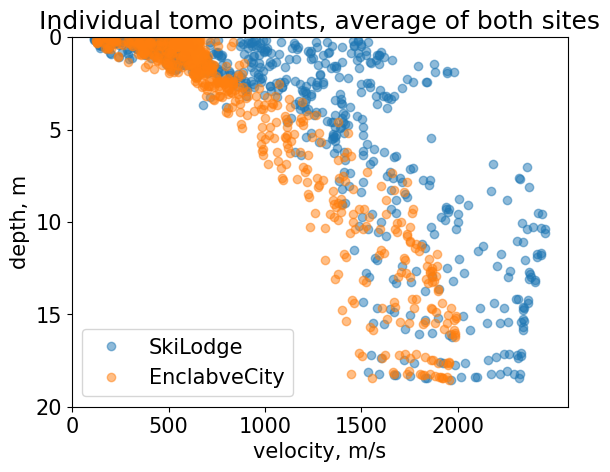

In [20]:
# Simple plot of individual points
plt.plot(vval, zval, 'o', label='SkiLodge',alpha=.5)
plt.plot(vval2, zval2, 'o', label='EnclabveCity',alpha=.5)
plt.xticks([0,500,1000,1500,2000])
plt.yticks([0,5,10,15,20])
plt.ylim([20,0])
plt.ylabel('depth, m')
plt.xlabel('velocity, m/s')
plt.title('Individual tomo points, average of both sites')
plt.legend()
plt.savefig('vel1d_vs_dep_allpoints_bothsites.pdf',format='pdf', dpi=400)
plt.show()
